# <a id='toc1_'></a>[<span style="color:yellow;">Art Conservation Analysis</span>](#toc0_)

- This code analyzes artwork images to help art conservation efforts using computer tools.  
- It detects brushstrokes (fine and large), main shapes, and simulates hidden layers like underdrawings.  
- It shows dominant brushstroke directions and displays results in clear visualizations.  
- Helps conservators study an artist’s techniques and artwork structure without touching the real piece.

**Table of contents**<a id='toc0_'></a>    
- [<span style="color:yellow;">Art Conservation Analysis</span>](#toc1_)    
- [Step 1: Import necessary libraries](#toc2_)    
- [Step 2: Load and preprocess artwork image](#toc3_)    
  - [Step 2.1: Load the local painting image](#toc3_1_)    
  - [Step 2.2: Print information about the loaded image](#toc3_2_)    
  - [Step 2.3: Resize to max 512x512 for better detail preservation](#toc3_3_)    
  - [Step 2.4: Convert to RGB for display (OpenCV uses BGR by default)](#toc3_4_)    
  - [Step 2.5: Display original image](#toc3_5_)    
- [Step 3: Preprocess for art analysis](#toc4_)    
  - [Step 3.1: Create different versions for different analyses](#toc4_1_)    
  - [Step 3.2: Apply mild blur to reduce noise but preserve fine details](#toc4_2_)    
  - [Step 3.3: Display preprocessing results](#toc4_3_)    
- [Step 4: Detect fine brushstrokes using Sobel operators](#toc5_)    
  - [Step 4.1: Use mild blur to preserve fine details](#toc5_1_)    
  - [Step 4.2: Convert to absolute values and scale](#toc5_2_)    
  - [Step 4.3: Combine and apply threshold to highlight fine details](#toc5_3_)    
  - [Step 4.4: Display brushstroke detection results](#toc5_4_)    
- [Step 5: Canny edge detection for identifying major forms and contours](#toc6_)    
  - [Step 5.1: Different thresholds to highlight different detail levels](#toc6_1_)    
  - [Step 5.2: Display Canny results](#toc6_2_)    
- [Step 6: Simulate hidden layer detection (like `underdrawings`)](#toc7_)    
  - [Step 6.1: Apply adaptive thresholding to highlight potential underdrawings](#toc7_1_)    
  - [Step 6.2: Combine with edge detection](#toc7_2_)    
  - [Step 6.3: Display hidden layer analysis](#toc7_3_)    
  - [Step 6.4 🎨 *Underdrawing: Art’s Hidden Prelude* ✨](#toc7_4_)    
- [Step 7: Compare edge detection methods for art analysis](#toc8_)    
- [Step 8: Quantitative analysis of brushstroke directions](#toc9_)    
  - [Step 8.1: Calculate edge orientation](#toc9_1_)    
  - [Step 8.2: Create histogram of orientations](#toc9_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc2_'></a>[Step 1: Import necessary libraries](#toc0_)

In [109]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns

In [110]:
# Set seaborn style for better visualization
sns.set_style("whitegrid")

In [111]:
# Enable inline plotting
%matplotlib inline

In [112]:
print("Libraries imported successfully!")

Libraries imported successfully!


# <a id='toc3_'></a>[Step 2: Load and preprocess artwork image](#toc0_)

## <a id='toc3_1_'></a>[Step 2.1: Load the local painting image](#toc0_)

In [113]:
image_path = 'blueberry_cake2.png'  # Using local file instead of URL
img = cv2.imread(image_path)

## <a id='toc3_2_'></a>[Step 2.2: Print information about the loaded image](#toc0_)

In [114]:
print(f"Loaded image from: {image_path}")

print(f"Image data type: {img.dtype}")
print(f"Image shape (height, width, channels): {img.shape}")
print(f"Image size (pixels): {img.size}")
print(f"Pixel value range: [{np.min(img)}, {np.max(img)}]")

Loaded image from: blueberry_cake2.png
Image data type: uint8
Image shape (height, width, channels): (1152, 1536, 3)
Image size (pixels): 5308416
Pixel value range: [0, 255]


## <a id='toc3_3_'></a>[Step 2.3: Resize to max 512x512 for better detail preservation](#toc0_)

In [115]:
max_size = 512 # restricting the image to a maximum of 512 pixels in either height or width
h, w = img.shape[:2]
scale = min(max_size/h, max_size/w)
img_resized = cv2.resize(img, (int(w*scale), int(h*scale)))

# Print resize information
print(f"\nResizing image...")
print(f"Original dimensions: {w}x{h}")
print(f"Resize scale factor: {scale:.4f}")
print(f"Resized dimensions: {img_resized.shape[1]}x{img_resized.shape[0]}")


Resizing image...
Original dimensions: 1536x1152
Resize scale factor: 0.3333
Resized dimensions: 512x384


## <a id='toc3_4_'></a>[Step 2.4: Convert to RGB for display (OpenCV uses BGR by default)](#toc0_)

In [116]:
img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
print(f"\nImage converted to RGB format for display")
print(f"RGB image shape: {img_rgb.shape}")
print(f"RGB image data type: {img_rgb.dtype}")


Image converted to RGB format for display
RGB image shape: (384, 512, 3)
RGB image data type: uint8


## <a id='toc3_5_'></a>[Step 2.5: Display original image](#toc0_)

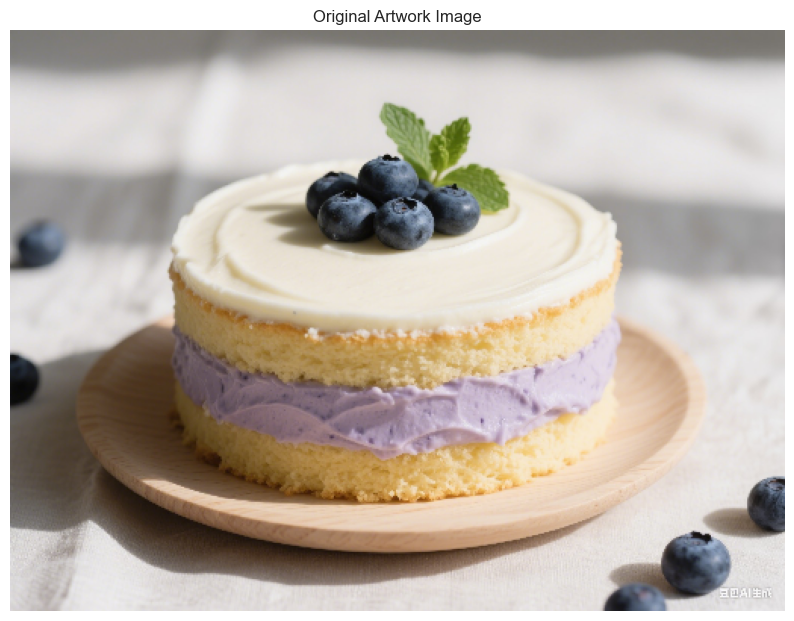

In [117]:
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.title("Original Artwork Image")
plt.axis("off")
plt.show()

* Painted by Leonardo da Vinci (1503–1519) during the High Renaissance, it’s a portrait of a Florentine woman (likely Lisa Gherardini).
* Known for sfumato—soft blending that gives its subject’s "enigmatic smile" a lifelike, elusive quality.
* Permanently displayed at Paris’ Louvre Museum; its 1911 theft and recovery made it a global sensation.
* The most recognizable artwork ever, a symbol of Renaissance genius and cultural intrigue.

# <a id='toc4_'></a>[Step 3: Preprocess for art analysis](#toc0_)

## <a id='toc4_1_'></a>[Step 3.1: Create different versions for different analyses](#toc0_)

In [118]:
gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

# Print grayscale information
print(f"\nConverted image to grayscale")
print(f"Grayscale image shape: {gray.shape}")
print(f"Grayscale image data type: {gray.dtype}")
print(f"Grayscale pixel value range: [{np.min(gray)}, {np.max(gray)}]")


Converted image to grayscale
Grayscale image shape: (384, 512)
Grayscale image data type: uint8
Grayscale pixel value range: [5, 251]


## <a id='toc4_2_'></a>[Step 3.2: Apply mild blur to reduce noise but preserve fine details](#toc0_)

In [119]:
blur_mild = cv2.GaussianBlur(gray, (3, 3), 0)  # Preserves fine brushstrokes
blur_medium = cv2.GaussianBlur(gray, (5, 5), 0)  # For general edge detection

# Print blur information
print(f"\nApplied Gaussian blurring")
print(f"Mild blur kernel size: (3, 3), sigma: 0")
print(f"Mild blur image shape: {blur_mild.shape}")
print(f"Medium blur kernel size: (5, 5), sigma: 0")
print(f"Medium blur image shape: {blur_medium.shape}")
print(f"Blurred image data type: {blur_mild.dtype}")


Applied Gaussian blurring
Mild blur kernel size: (3, 3), sigma: 0
Mild blur image shape: (384, 512)
Medium blur kernel size: (5, 5), sigma: 0
Medium blur image shape: (384, 512)
Blurred image data type: uint8


## <a id='toc4_3_'></a>[Step 3.3: Display preprocessing results](#toc0_)

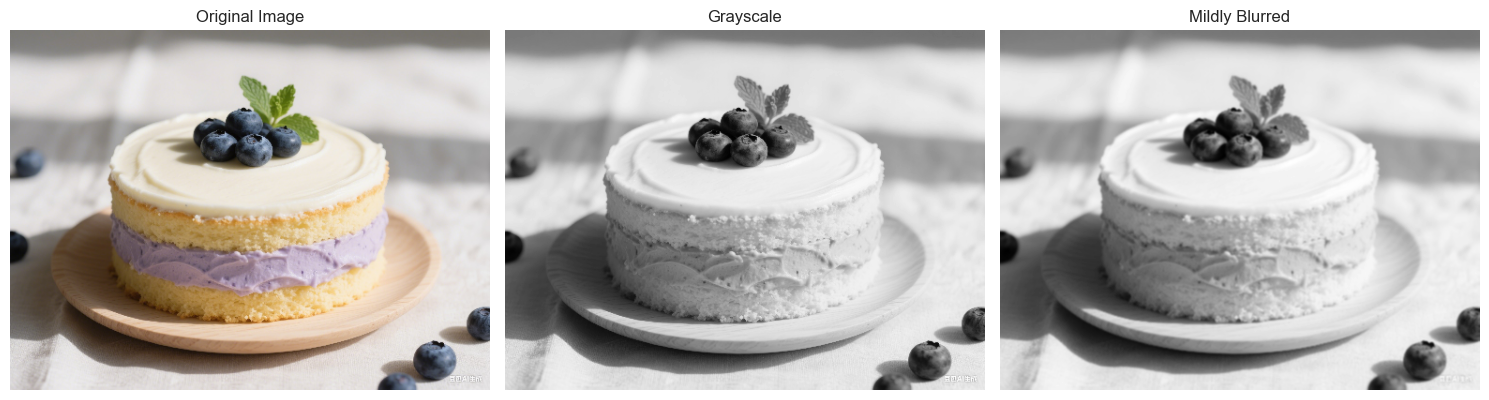

In [120]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(blur_mild, cmap="gray")
plt.title("Mildly Blurred")
plt.axis("off")

plt.tight_layout()
plt.show()

# <a id='toc5_'></a>[Step 4: Detect fine brushstrokes using Sobel operators](#toc0_)

## <a id='toc5_1_'></a>[Step 4.1: Use mild blur to preserve fine details](#toc0_)

In [121]:
sobel_x = cv2.Sobel(blur_mild, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(blur_mild, cv2.CV_64F, 0, 1, ksize=3)

# Print Sobel operator information
print(f"\nApplied Sobel operators for edge detection")
print(f"Sobel X data type: {sobel_x.dtype}")
print(f"Sobel X shape: {sobel_x.shape}")
print(f"Sobel X value range: [{np.min(sobel_x):.2f}, {np.max(sobel_x):.2f}]")
print(f"Sobel Y data type: {sobel_y.dtype}")
print(f"Sobel Y shape: {sobel_y.shape}")
print(f"Sobel Y value range: [{np.min(sobel_y):.2f}, {np.max(sobel_y):.2f}]")


Applied Sobel operators for edge detection
Sobel X data type: float64
Sobel X shape: (384, 512)
Sobel X value range: [-555.00, 476.00]
Sobel Y data type: float64
Sobel Y shape: (384, 512)
Sobel Y value range: [-602.00, 451.00]


## <a id='toc5_2_'></a>[Step 4.2: Convert to absolute values and scale](#toc0_)

In [122]:
sobel_x_abs_brush = np.uint8(np.absolute(sobel_x))
sobel_y_abs_brush = np.uint8(np.absolute(sobel_y))

# Print absolute Sobel information
print(f"\nProcessed absolute values of Sobel operators")
print(f"Absolute Sobel X data type: {sobel_x_abs_brush.dtype}")
print(f"Absolute Sobel X value range: [{np.min(sobel_x_abs_brush)}, {np.max(sobel_x_abs_brush)}]")
print(f"Absolute Sobel Y data type: {sobel_y_abs_brush.dtype}")
print(f"Absolute Sobel Y value range: [{np.min(sobel_y_abs_brush)}, {np.max(sobel_y_abs_brush)}]")


Processed absolute values of Sobel operators
Absolute Sobel X data type: uint8
Absolute Sobel X value range: [0, 254]
Absolute Sobel Y data type: uint8
Absolute Sobel Y value range: [0, 255]


## <a id='toc5_3_'></a>[Step 4.3: Combine and apply threshold to highlight fine details](#toc0_)

In [123]:
sobel_combined_brush = cv2.addWeighted(sobel_x_abs_brush, 0.5, sobel_y_abs_brush, 0.5, 0)
_, sobel_brush_thresh = cv2.threshold(sobel_combined_brush, 20, 255, cv2.THRESH_BINARY)

# Print combined Sobel information
print(f"\nCombined Sobel results")
print(f"Combined Sobel shape: {sobel_combined_brush.shape}")
print(f"Combined Sobel value range: [{np.min(sobel_combined_brush)}, {np.max(sobel_combined_brush)}]")
print(f"Threshold applied: values > 20 set to 255 (white), others to 0 (black)")
print(f"Thresholded Sobel shape: {sobel_brush_thresh.shape}")
print(f"Thresholded Sobel unique values: {np.unique(sobel_brush_thresh)}")


Combined Sobel results
Combined Sobel shape: (384, 512)
Combined Sobel value range: [0, 251]
Threshold applied: values > 20 set to 255 (white), others to 0 (black)
Thresholded Sobel shape: (384, 512)
Thresholded Sobel unique values: [  0 255]


## <a id='toc5_4_'></a>[Step 4.4: Display brushstroke detection results](#toc0_)

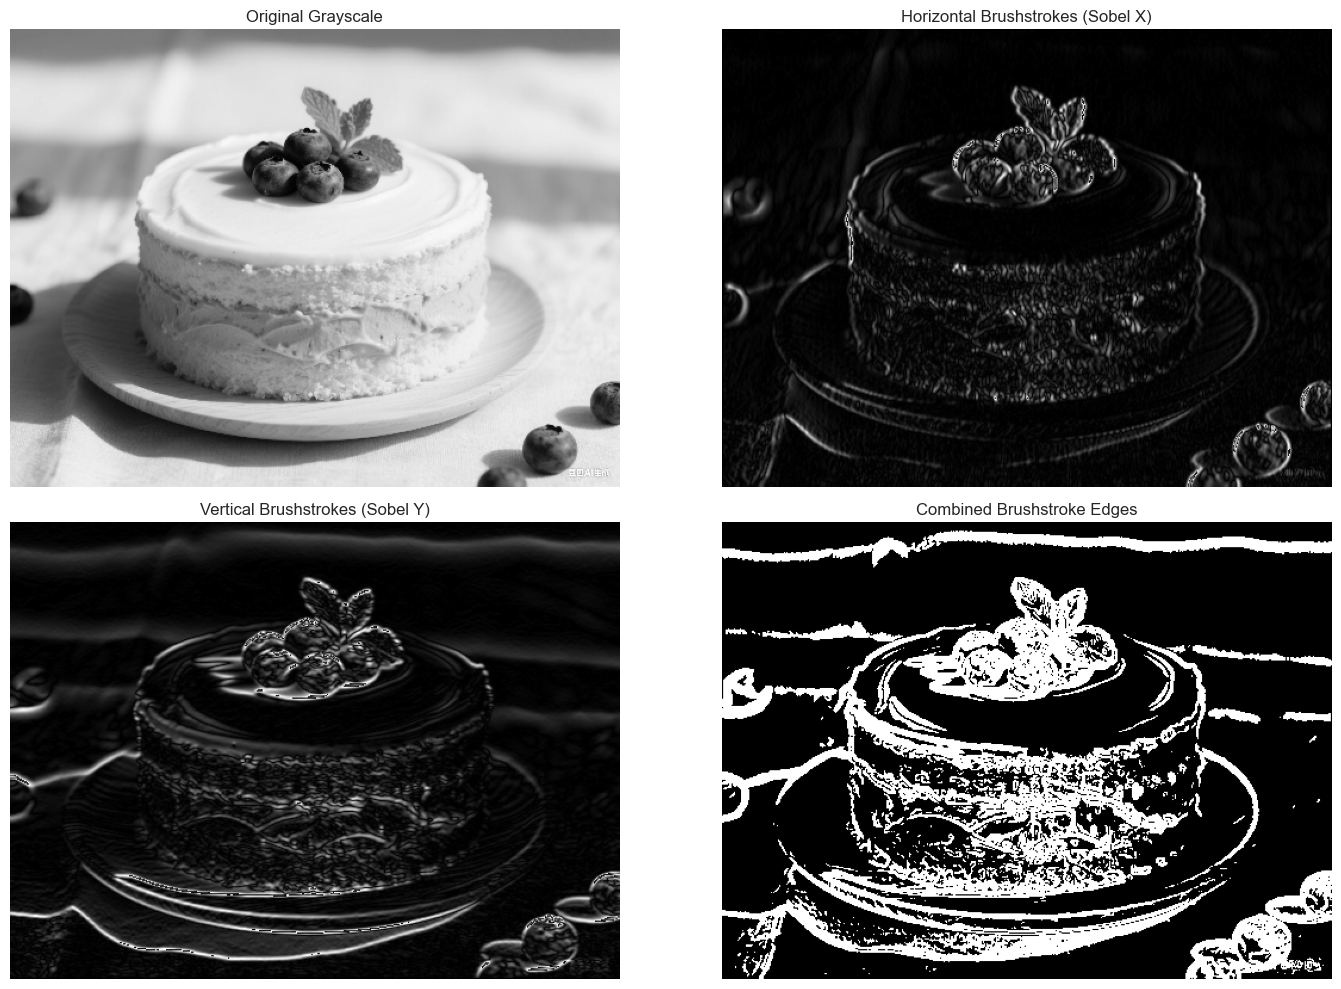

In [124]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(sobel_x_abs_brush, cmap="gray")
plt.title("Horizontal Brushstrokes (Sobel X)")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(sobel_y_abs_brush, cmap="gray")
plt.title("Vertical Brushstrokes (Sobel Y)")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(sobel_brush_thresh, cmap="gray")
plt.title("Combined Brushstroke Edges")
plt.axis("off")

plt.tight_layout()
plt.show()

# <a id='toc6_'></a>[Step 5: Canny edge detection for identifying major forms and contours](#toc0_)

## <a id='toc6_1_'></a>[Step 5.1: Different thresholds to highlight different detail levels](#toc0_)

In [125]:
canny_fine = cv2.Canny(blur_mild, 10, 50)    # Fine details
canny_medium = cv2.Canny(blur_medium, 30, 100)  # Medium details
canny_coarse = cv2.Canny(blur_medium, 70, 200)  # Major contours

# Print Canny edge detection information
print(f"\nApplied Canny edge detection with varying thresholds")
print(f"Fine Canny thresholds: 10 (lower), 50 (upper)")
print(f"Fine Canny shape: {canny_fine.shape}")
print(f"Fine Canny unique values: {np.unique(canny_fine)}")
print(f"Medium Canny thresholds: 30 (lower), 100 (upper)")
print(f"Medium Canny shape: {canny_medium.shape}")
print(f"Coarse Canny thresholds: 70 (lower), 200 (upper)")
print(f"Coarse Canny shape: {canny_coarse.shape}")


Applied Canny edge detection with varying thresholds
Fine Canny thresholds: 10 (lower), 50 (upper)
Fine Canny shape: (384, 512)
Fine Canny unique values: [  0 255]
Medium Canny thresholds: 30 (lower), 100 (upper)
Medium Canny shape: (384, 512)
Coarse Canny thresholds: 70 (lower), 200 (upper)
Coarse Canny shape: (384, 512)


## <a id='toc6_2_'></a>[Step 5.2: Display Canny results](#toc0_)

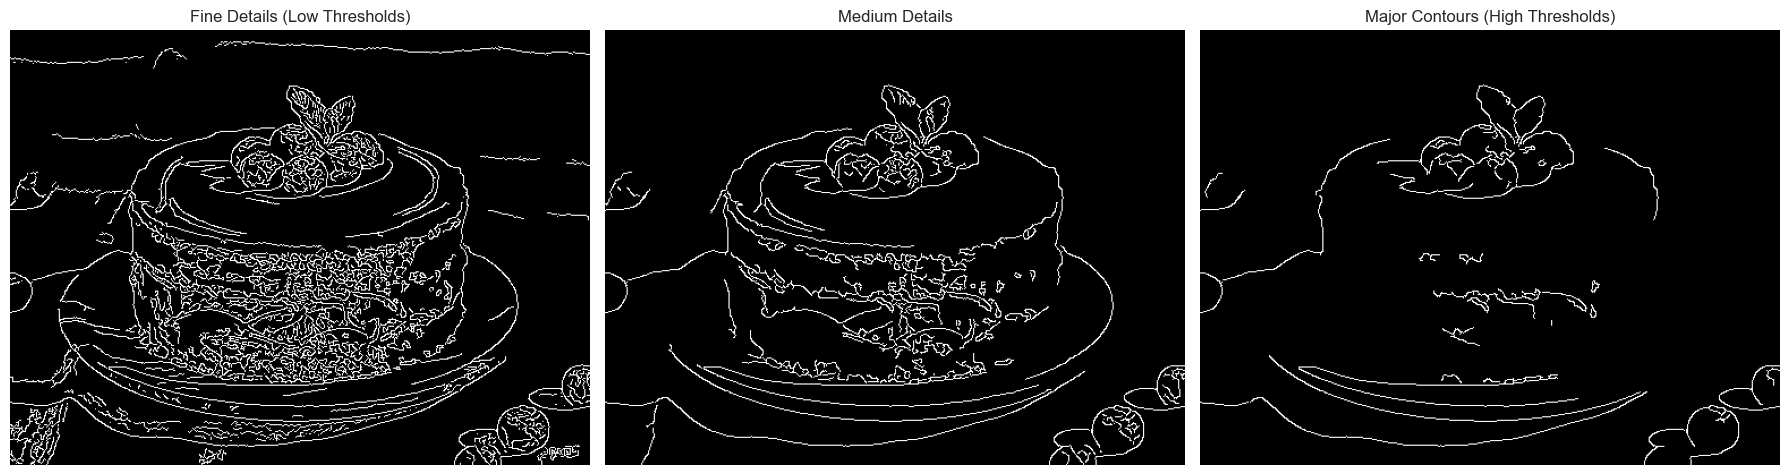

In [126]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(canny_fine, cmap="gray")
plt.title("Fine Details (Low Thresholds)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(canny_medium, cmap="gray")
plt.title("Medium Details")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(canny_coarse, cmap="gray")
plt.title("Major Contours (High Thresholds)")
plt.axis("off")

plt.tight_layout()
plt.show()

# <a id='toc7_'></a>[Step 6: Simulate hidden layer detection (like `underdrawings`)](#toc0_)

* Create a simulated X-ray view by enhancing edges in darker regions
* This mimics how conservationists use imaging techniques to see underlayers

## <a id='toc7_1_'></a>[Step 6.1: Apply adaptive thresholding to highlight potential underdrawings](#toc0_)

In [127]:
adaptive_thresh = cv2.adaptiveThreshold(
    gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV, 11, 2
)

# Print adaptive threshold information
print(f"\nApplied adaptive thresholding")
print(f"Adaptive threshold method: Gaussian")
print(f"Block size: 11, C value: 2")
print(f"Adaptive threshold shape: {adaptive_thresh.shape}")
print(f"Adaptive threshold unique values: {np.unique(adaptive_thresh)}")


Applied adaptive thresholding
Adaptive threshold method: Gaussian
Block size: 11, C value: 2
Adaptive threshold shape: (384, 512)
Adaptive threshold unique values: [  0 255]


## <a id='toc7_2_'></a>[Step 6.2: Combine with edge detection](#toc0_)

In [128]:
hidden_edges = cv2.bitwise_and(adaptive_thresh, canny_fine)

# Print hidden edges information
print(f"\nCreated simulated hidden layer detection")
print(f"Combined adaptive threshold with fine Canny edges using bitwise AND")
print(f"Hidden edges shape: {hidden_edges.shape}")
print(f"Hidden edges unique values: {np.unique(hidden_edges)}")


Created simulated hidden layer detection
Combined adaptive threshold with fine Canny edges using bitwise AND
Hidden edges shape: (384, 512)
Hidden edges unique values: [  0 255]


## <a id='toc7_3_'></a>[Step 6.3: Display hidden layer analysis](#toc0_)

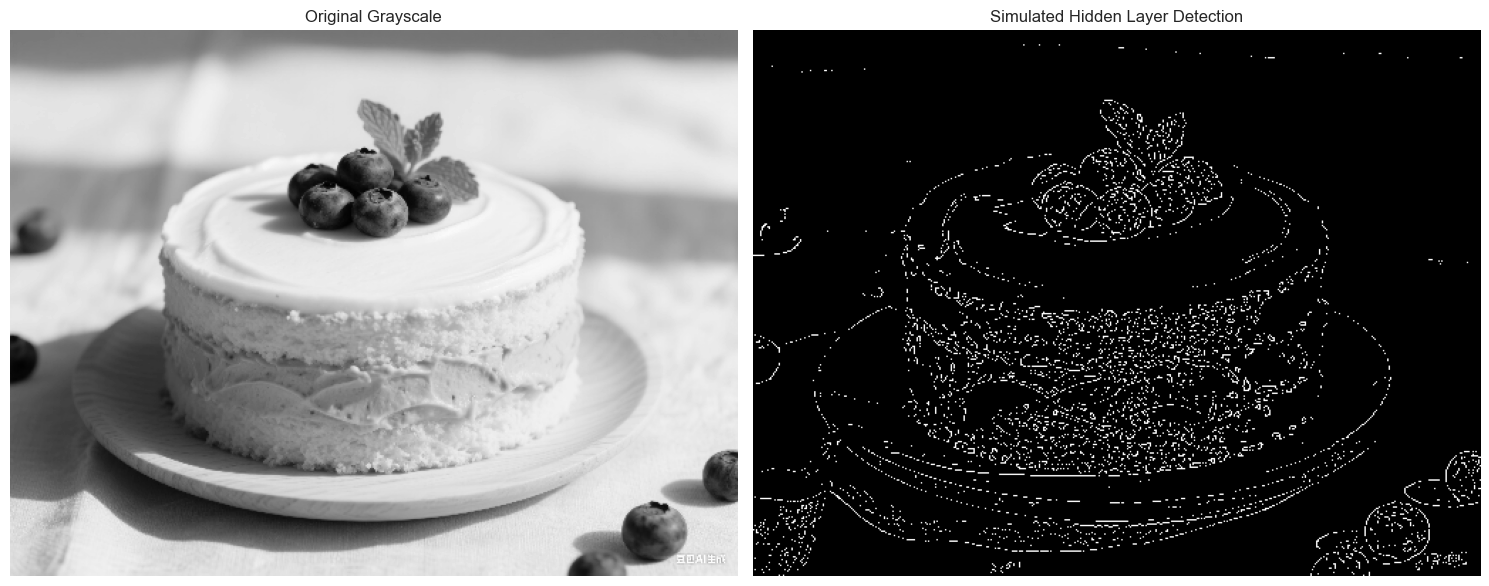

In [129]:
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hidden_edges, cmap="gray")
plt.title("Simulated Hidden Layer Detection")
plt.axis("off")

plt.tight_layout()
plt.show()

## <a id='toc7_4_'></a>[Step 6.4 🎨 *Underdrawing: Art’s Hidden Prelude* ✨](#toc0_)
- Artists’ hidden prep layer to map contours/composition before paint.  
- Made with charcoal/light pencil—some show through, others hide.  
- Conservators use it to see an artist’s creative process.

# <a id='toc8_'></a>[Step 7: Compare edge detection methods for art analysis](#toc0_)

In [130]:
print("\nComparing edge detection methods for art conservation applications")


Comparing edge detection methods for art conservation applications


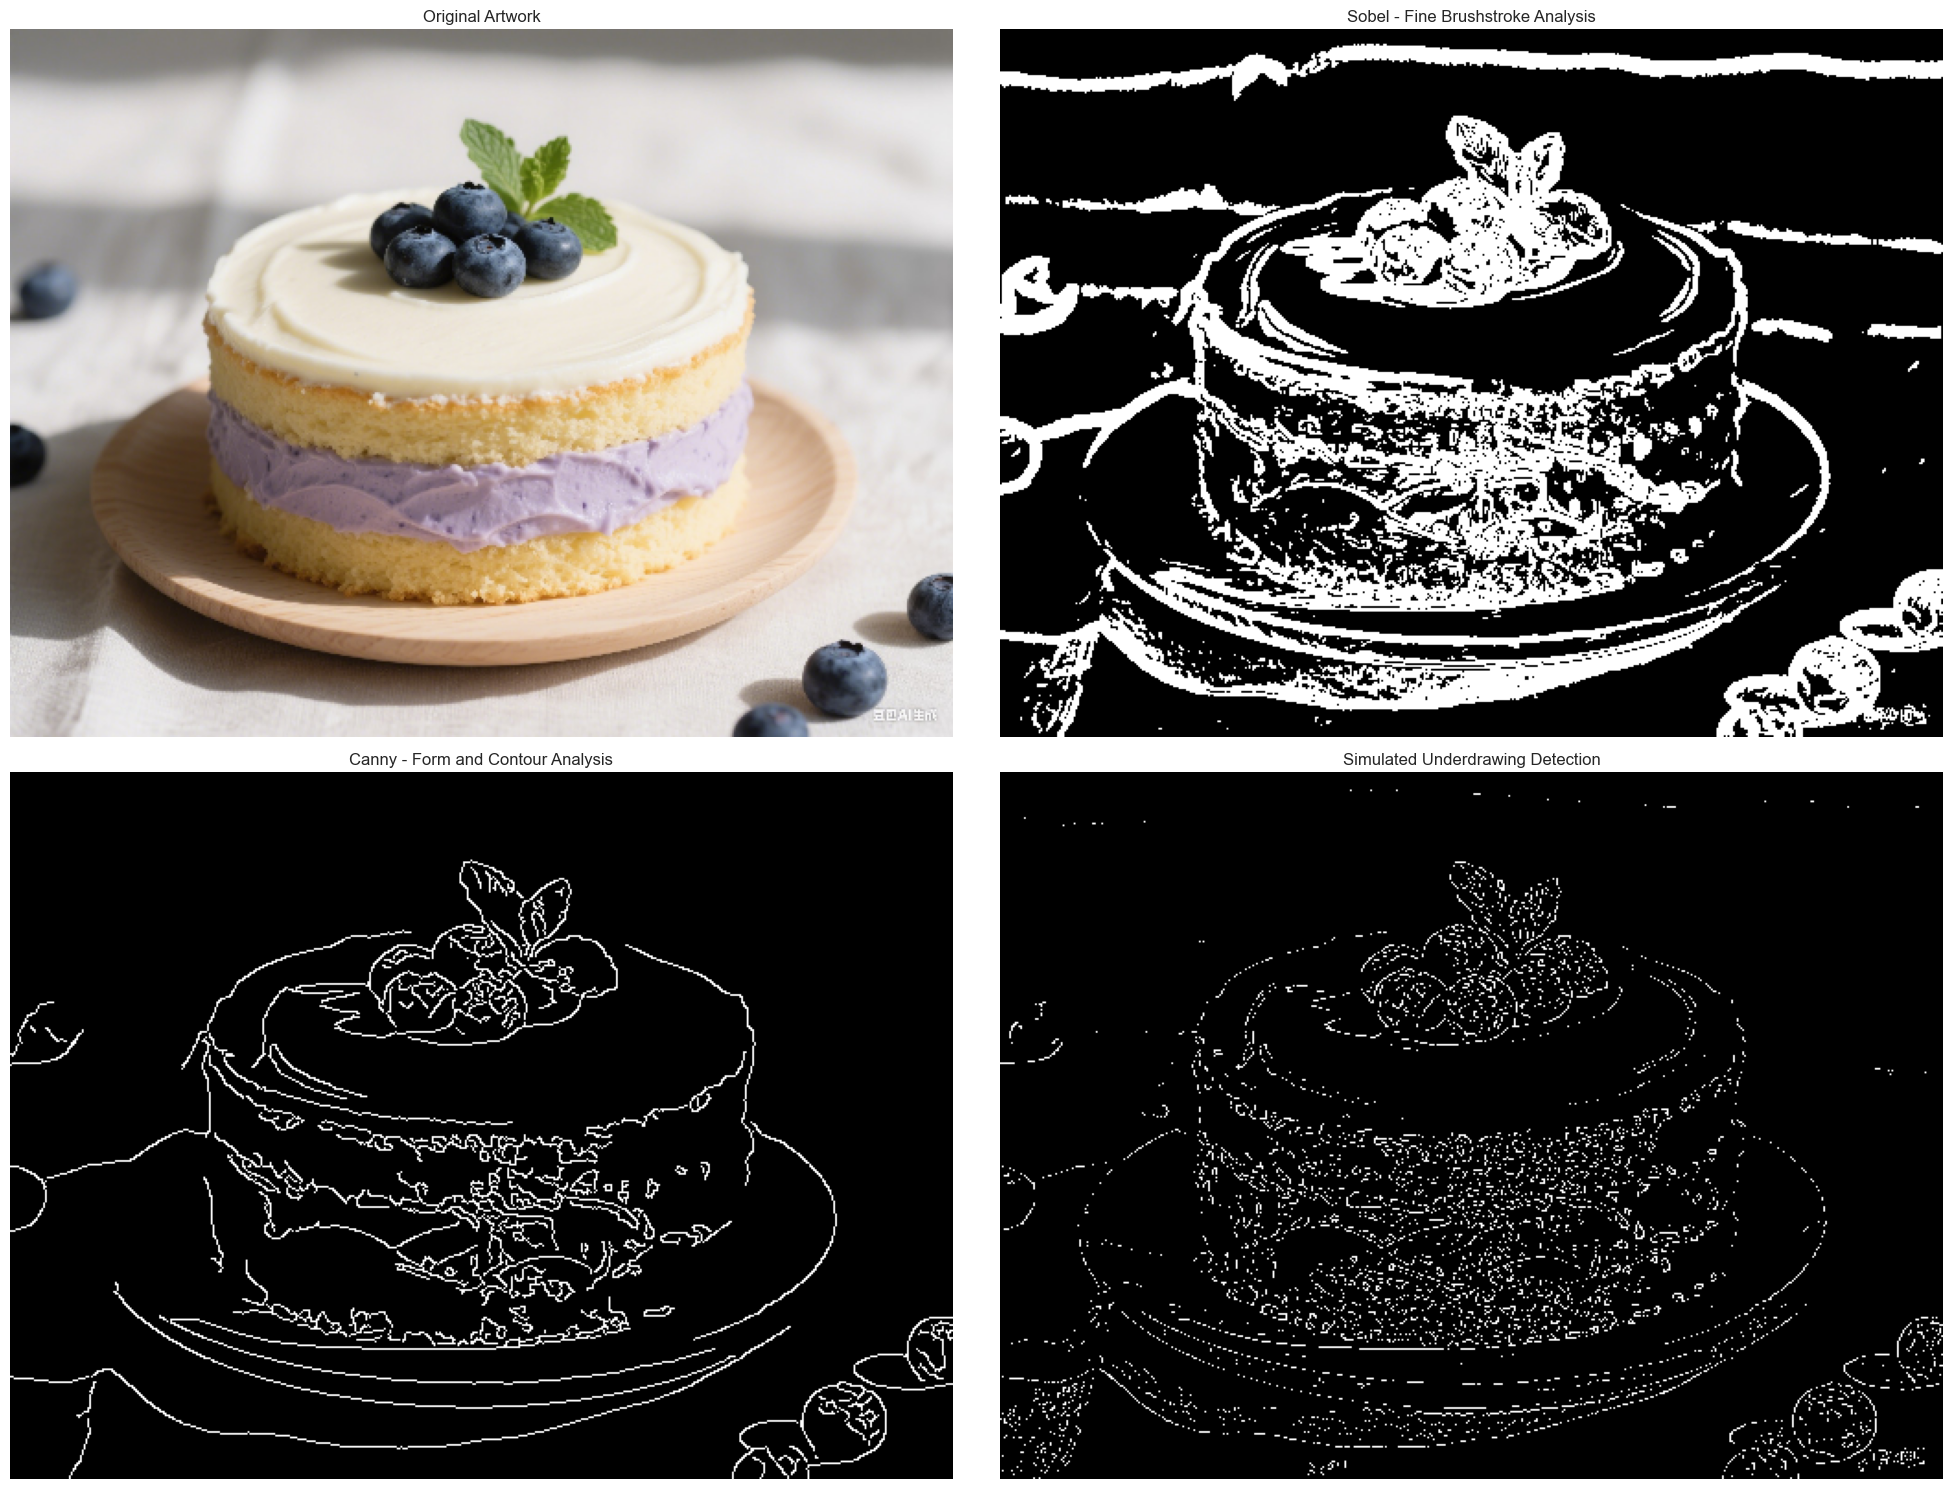

In [131]:
plt.figure(figsize=(20, 15))

plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Artwork")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(sobel_brush_thresh, cmap="gray")
plt.title("Sobel - Fine Brushstroke Analysis")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(canny_medium, cmap="gray")
plt.title("Canny - Form and Contour Analysis")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(hidden_edges, cmap="gray")
plt.title("Simulated Underdrawing Detection")
plt.axis("off")

plt.tight_layout()
plt.show()

# <a id='toc9_'></a>[Step 8: Quantitative analysis of brushstroke directions](#toc0_)

## <a id='toc9_1_'></a>[Step 8.1: Calculate edge orientation](#toc0_)

In [132]:
orientation = np.arctan2(sobel_y, sobel_x) * (180 / np.pi) % 180  # Reuse variables

In [133]:
# Print orientation information
print(f"\nCalculated edge orientations")
print(f"Orientation data type: {orientation.dtype}")
print(f"Orientation shape: {orientation.shape}")
print(f"Orientation value range: [{np.min(orientation):.2f}°, {np.max(orientation):.2f}°]")
print(f"Mean orientation: {np.mean(orientation):.2f}°")
print(f"Median orientation: {np.median(orientation):.2f}°")


Calculated edge orientations
Orientation data type: float64
Orientation shape: (384, 512)
Orientation value range: [0.00°, 179.73°]
Mean orientation: 81.91°
Median orientation: 90.00°


## <a id='toc9_2_'></a>[Step 8.2: Create histogram of orientations](#toc0_)

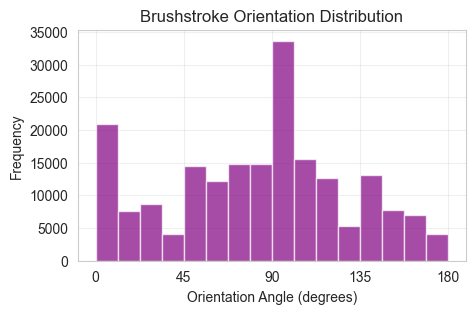

In [134]:
plt.figure(figsize=(5, 3))
plt.hist(orientation.flatten(), bins=16, range=(0, 180), color='purple', alpha=0.7)
plt.title('Brushstroke Orientation Distribution')
plt.xlabel('Orientation Angle (degrees)')
plt.ylabel('Frequency')
plt.xticks(np.arange(0, 181, 45))
plt.grid(True, alpha=0.3)
plt.show()

In [135]:
# %%
print("\nArt conservation analysis complete!")
print("Key findings:")
print("- Sobel edge detection highlights fine brushstroke details")
print("- Canny with medium thresholds shows major forms and contours")
print("- Orientation analysis reveals dominant brushstroke directions")
print("- Simulated hidden layer detection shows potential underdrawings")


Art conservation analysis complete!
Key findings:
- Sobel edge detection highlights fine brushstroke details
- Canny with medium thresholds shows major forms and contours
- Orientation analysis reveals dominant brushstroke directions
- Simulated hidden layer detection shows potential underdrawings
